# Notebook 05 - RoBERTa Transformer Sentiment Analysis

Runs a pretrained transformer (`cardiffnlp/twitter-roberta-base-sentiment-latest`) on the augmented sunscreen corpus and compares the results against the VADER sentiment analysis from notebook 04, addressing VADER's known limitations with sarcasm and domain-specific language.

**Input:** `../data/processed/df_sunscreen_final.csv` (notebook 04's output - reused here for its spaCy `entities` column, so brand detection is consistent with notebook 04 instead of re-implementing string matching)  
**Output:** figures in `../figures/`

In [1]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 55990.91it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
import pandas as pd

# notebook 04's output: same 268 documents as the augmented dataset, plus
# VADER sentiment and spaCy entities, which we reuse below for brand detection
df = pd.read_csv('../data/processed/df_sunscreen_final.csv')
print(f"Shape: {df.shape}")

Shape: (268, 16)


## RoBERTa Sentiment Analysis

`cardiffnlp/twitter-roberta-base-sentiment-latest` is a RoBERTa model fine-tuned on ~124M tweets for 3-class sentiment classification (positive / neutral / negative). Unlike VADER's lexicon-and-rules approach, it is a transformer trained on real social media text, which should make it more robust to sarcasm and informal phrasing - the two limitations flagged at the end of notebook 04.

Each document's `Text` is truncated to 512 tokens (the model's max input length) before inference.

In [3]:
# RoBERTa expects max 512 tokens - truncate long texts
def get_roberta_sentiment(text):
    if pd.isna(text):
        return None, None
    result = sentiment_pipeline(text[:512], truncation=True)[0]
    return result['label'], result['score']

print("Running RoBERTa...")
df[['roberta_label', 'roberta_score']] = df['Text'].apply(
    lambda x: pd.Series(get_roberta_sentiment(x))
)

print("Done!")
print(df['roberta_label'].value_counts())

Running RoBERTa...
Done!
roberta_label
negative    110
neutral      99
positive     59
Name: count, dtype: int64


## VADER vs RoBERTa: Sentiment Distribution Comparison

The chart below compares RoBERTa's sentiment distribution against VADER's results from notebook 04.

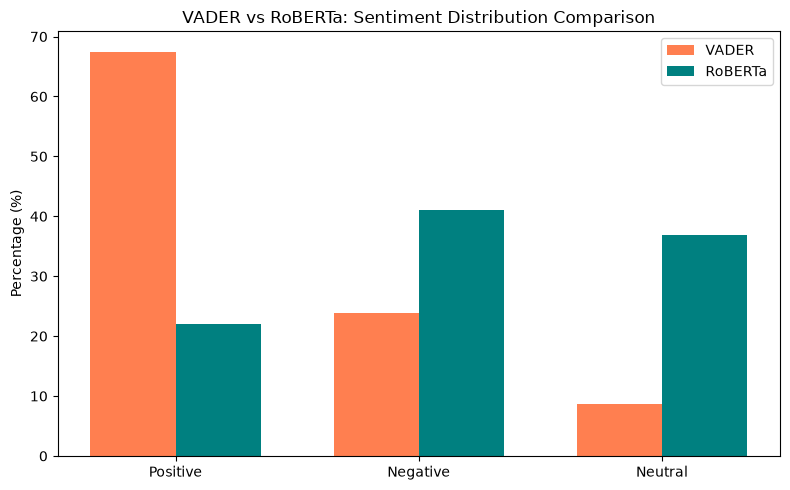

In [4]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Positive', 'Negative', 'Neutral']
vader = [67.5, 23.9, 8.6]
roberta = [22.0, 41.0, 36.9]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, vader, width, label='VADER', color='coral')
ax.bar(x + width/2, roberta, width, label='RoBERTa', color='teal')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage (%)')
ax.set_title('VADER vs RoBERTa: Sentiment Distribution Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/vader_vs_roberta.png', dpi=150)
plt.show()

RoBERTa paints a markedly different picture from VADER: positive sentiment drops from 67.5% to 22.0%, while negative sentiment rises from 23.9% to 41.0% and neutral rises from 8.6% to 36.9%. This is consistent with VADER over-crediting sarcastic or hedged language as positive - RoBERTa's transformer architecture appears to pick up the more critical tone that a purely lexicon-based approach misses.

## Brand Sentiment Analysis (RoBERTa)

Mean RoBERTa sentiment score (positive=1, neutral=0, negative=-1) per brand, using the same greenwashing vs. reef-safe grouping as notebook 04.

In [5]:
# map RoBERTa labels to numeric scores for comparison
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['roberta_score_numeric'] = df['roberta_label'].map(label_map)

# same entity-based brand detection as notebook 04, instead of string matching -
# str.contains('Banana Boat') also matches it inside longer strings/other brands'
# mentions and misses cases spaCy's entity ruler correctly resolves
import ast

def mentions_brand(entities_or_str, brand):
    try:
        if isinstance(entities_or_str, list):
            entities = entities_or_str
        else:
            entities = ast.literal_eval(entities_or_str)
    except (ValueError, SyntaxError, TypeError):
        return False
    for entity_text, entity_label in entities:
        if brand.lower() in entity_text.lower():
            return True
    return False

brands_of_interest = [
    'Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
    'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum'
]

brand_roberta = {}
for brand in brands_of_interest:
    mask = df['entities'].apply(mentions_brand, args=(brand,))
    docs = df[mask]
    if len(docs) > 0:
        brand_roberta[brand] = docs['roberta_score_numeric'].mean()

brand_roberta_df = pd.Series(brand_roberta).sort_values()
print(brand_roberta_df)

Banana Boat       -0.533333
Hawaiian Tropic   -0.521739
Coppertone        -0.500000
Neutrogena        -0.076923
Raw Elements       0.047619
Stream2Sea         0.173913
Sun Bum            0.250000
Thinksport         0.266667
Badger Balm        0.444444
dtype: float64


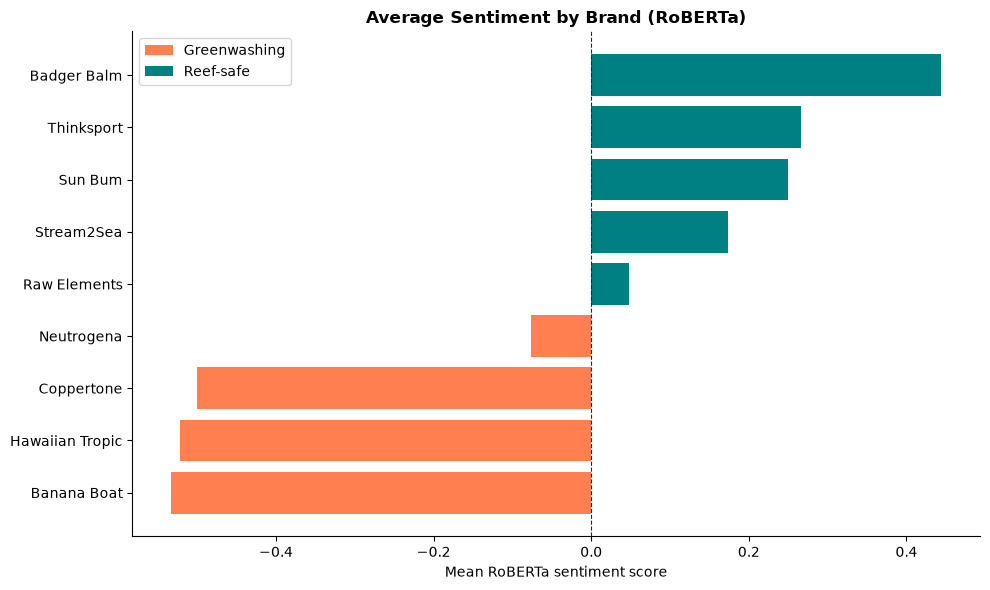

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = ['coral' if v < 0 else 'teal' for v in brand_roberta_df.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(brand_roberta_df.index, brand_roberta_df.values, color=colors)
ax.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean RoBERTa sentiment score')
ax.set_title('Average Sentiment by Brand (RoBERTa)', fontweight='bold')
legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]
ax.legend(handles=legend_elements)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/brand_sentiment_roberta.png', dpi=150)
plt.show()

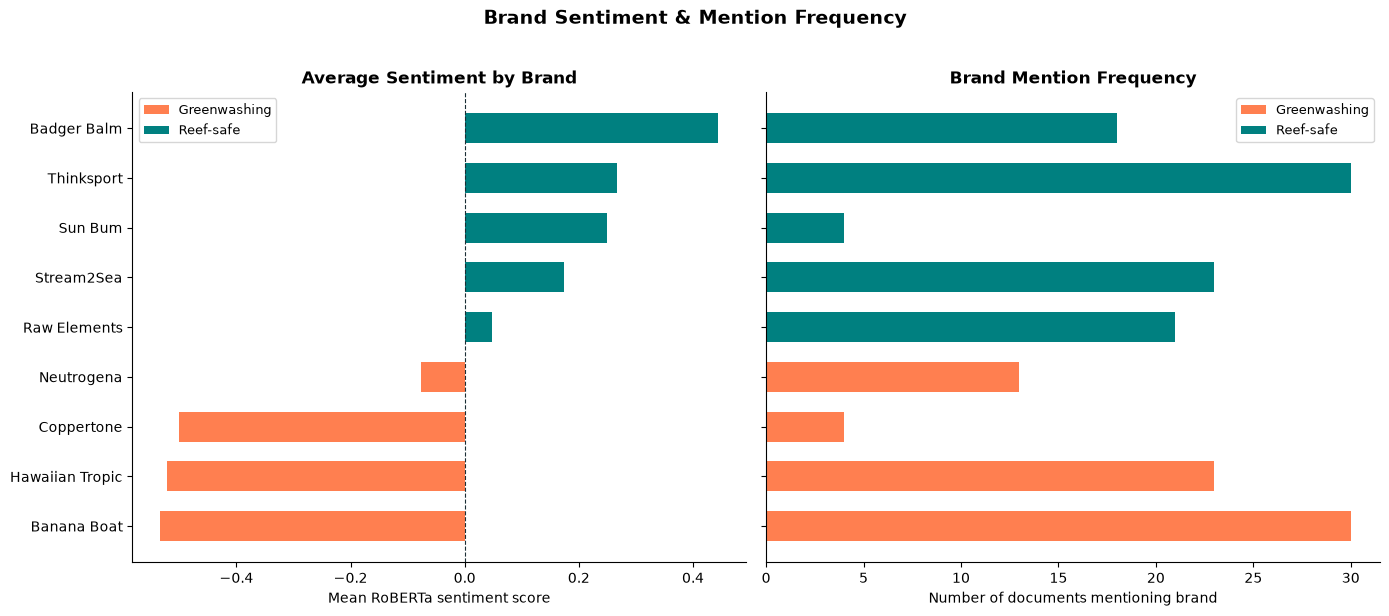

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

brands = ['Banana Boat', 'Hawaiian Tropic', 'Neutrogena', 'Coppertone',
          'Stream2Sea', 'Raw Elements', 'Thinksport', 'Badger Balm', 'Sun Bum']

categories = {
    'Banana Boat': 'Greenwashing', 'Hawaiian Tropic': 'Greenwashing',
    'Neutrogena': 'Greenwashing', 'Coppertone': 'Greenwashing',
    'Stream2Sea': 'Reef-safe', 'Raw Elements': 'Reef-safe',
    'Thinksport': 'Reef-safe', 'Badger Balm': 'Reef-safe', 'Sun Bum': 'Reef-safe'
}

# mention counts (entity-based, same mentions_brand() defined above)
mention_counts = {}
for brand in brands:
    mask = df['entities'].apply(mentions_brand, args=(brand,))
    mention_counts[brand] = mask.sum()

# sort by RoBERTa sentiment ascending (same order in both charts)
sorted_brands = sorted(brands, key=lambda b: brand_roberta.get(b, 0))
sorted_scores = [brand_roberta.get(b, 0) for b in sorted_brands]
sorted_counts = [mention_counts.get(b, 0) for b in sorted_brands]
colors = ['coral' if categories[b] == 'Greenwashing' else 'teal' for b in sorted_brands]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

legend_elements = [Patch(facecolor='coral', label='Greenwashing'),
                   Patch(facecolor='teal', label='Reef-safe')]

# LEFT: sentiment
ax1.barh(sorted_brands, sorted_scores, color=colors, height=0.6)
ax1.axvline(x=0, color='#1A2E35', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Mean RoBERTa sentiment score')
ax1.set_title('Average Sentiment by Brand', fontweight='bold')
ax1.legend(handles=legend_elements, fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# RIGHT: mention frequency (same order)
ax2.barh(sorted_brands, sorted_counts, color=colors, height=0.6)
ax2.set_xlabel('Number of documents mentioning brand')
ax2.set_title('Brand Mention Frequency', fontweight='bold')
ax2.set_yticklabels([])  # hide duplicate y-axis labels
ax2.legend(handles=legend_elements, fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Brand Sentiment & Mention Frequency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/brand_sentiment_roberta_combined.png', dpi=150, bbox_inches='tight')
plt.show()

The brand-level pattern mirrors VADER's findings: all four greenwashing-labelled brands (Banana Boat, Hawaiian Tropic, Coppertone, Neutrogena) score negative, while all five reef-safe brands score positive. Banana Boat is the most negative brand (-0.53) and Badger Balm the most positive (+0.44), consistent with the ACCC case targeting Edgewell - the parent company of Banana Boat and Hawaiian Tropic - for false reef-safe claims.

Raw Elements is the lowest-scoring reef-safe brand (+0.05, barely positive) rather than a negative outlier - a smaller version of the pattern flagged qualitatively in notebook 04, where a document expressing betrayal toward Banana Boat also names Raw Elements as the trusted alternative. Because both models score sentiment at the document level rather than the entity level, the negative tone of the surrounding text pulls this positive brand mention down toward neutral.

## ACCC Case Analysis (RoBERTa)

Sentiment distribution of documents mentioning the ACCC case (`ACCC`, `Edgewell`, `Federal Court`), re-analysed with RoBERTa.

In [8]:
accc_keywords = ['ACCC', 'Edgewell', 'Federal Court']
mask_accc = df['Text'].str.contains('|'.join(accc_keywords), case=False, na=False)
df_accc = df[mask_accc].copy()
print(f"ACCC docs: {len(df_accc)}")
print(df_accc['roberta_label'].value_counts())

ACCC docs: 75
roberta_label
neutral     36
negative    31
positive     8
Name: count, dtype: int64


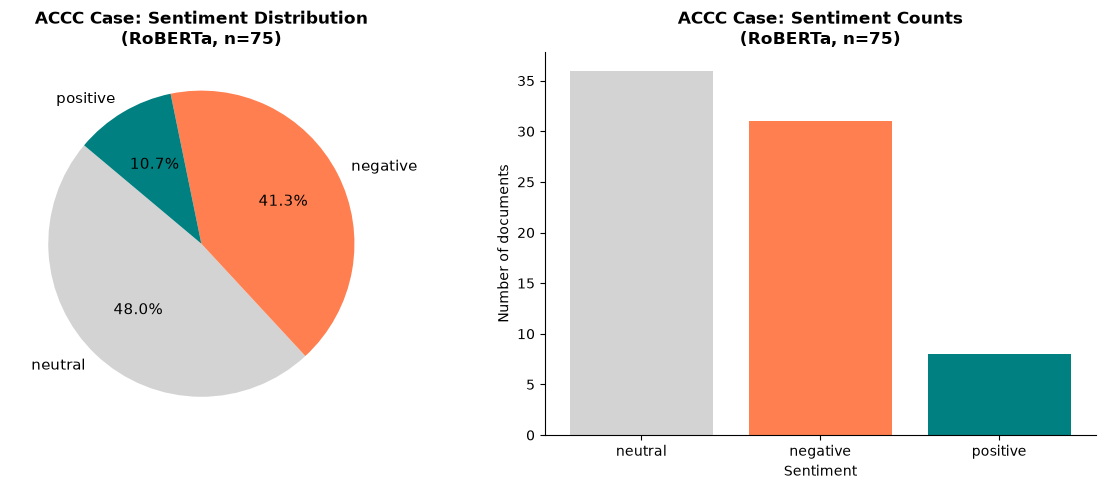

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# pie chart
sentiment_counts = df_accc['roberta_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax1.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=140,
        textprops={'fontsize': 11})
ax1.set_title(f'ACCC Case: Sentiment Distribution\n(RoBERTa, n={len(df_accc)})', fontweight='bold')

# bar chart
ax2.bar(sentiment_counts.index, sentiment_counts.values,
        color=[pie_colors[s] for s in sentiment_counts.index])
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Number of documents')
ax2.set_title(f'ACCC Case: Sentiment Counts\n(RoBERTa, n={len(df_accc)})', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/accc_roberta.png', dpi=150, bbox_inches='tight')
plt.show()

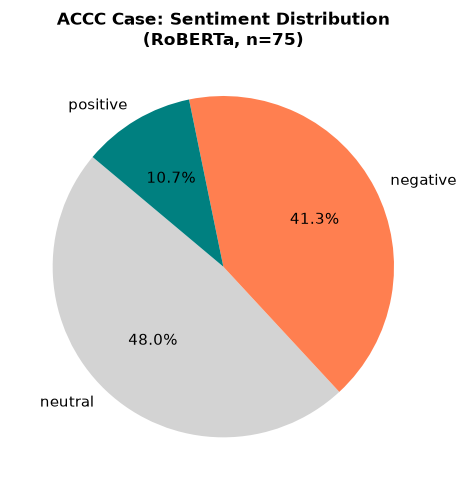

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

sentiment_counts = df_accc['roberta_label'].value_counts()
pie_colors = {'positive': 'teal', 'negative': 'coral', 'neutral': '#d3d3d3'}
colors_pie = [pie_colors[s] for s in sentiment_counts.index]

ax.pie(sentiment_counts.values,
       labels=sentiment_counts.index,
       autopct='%1.1f%%',
       colors=colors_pie,
       startangle=140,
       textprops={'fontsize': 11})
ax.set_title(f'ACCC Case: Sentiment Distribution\n(RoBERTa, n={len(df_accc)})', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/accc_roberta_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

The sharpest divergence between the two models is on the ACCC case documents themselves: VADER reads the 75 ACCC-related documents as overwhelmingly positive (54 positive, 20 negative, 1 neutral - 72% positive), while RoBERTa reads the same documents as mostly negative/neutral (31 negative, 36 neutral, 8 positive - only 10.7% positive). This is the clearest evidence for the sarcasm-detection hypothesis raised in notebook 04: comments celebrating the ACCC ruling ("finally called out", "about time") read as lexically positive to VADER but are correctly identified by RoBERTa as expressing negative sentiment toward Edgewell/Banana Boat/Hawaiian Tropic.

The same pattern holds at the corpus level: negative sentiment nearly doubles from VADER to RoBERTa (23.9% → 41.0%) and positive sentiment drops by two-thirds (67.5% → 22.0%).

Despite this shift in overall distribution, the brand-level ranking is consistent across both models: greenwashing-labelled brands (Banana Boat, Hawaiian Tropic, Coppertone, Neutrogena) skew negative, reef-safe brands skew positive. The core finding - that public discourse treats reef-safe brands and greenwashing brands differently, and treats the ACCC ruling critically once sarcasm is accounted for - holds regardless of which sentiment model is used.

### Limitations and Next Steps

Both models score sentiment at the document level, not the entity level. As flagged qualitatively in notebook 04, Raw Elements is sometimes mentioned inside otherwise negative documents (e.g. a customer expressing betrayal toward Banana Boat while praising Raw Elements as the alternative) - the negative document-level score is directed at the greenwashing brand, not at Raw Elements itself. This is consistent with Raw Elements being the lowest-scoring reef-safe brand (+0.05) despite being viewed favourably whenever it is actually discussed. A finer-grained approach (e.g. aspect-based sentiment analysis, or sentiment scoped to the sentence/clause mentioning the brand rather than the full document) would separate these cases.

RoBERTa also truncates each document to its first 512 tokens; in this corpus, only 2 of the 268 documents (0.7%) exceed that length, so truncation has a negligible effect on the results reported here. For longer-form text it would still be worth chunking (splitting into overlapping windows, scoring each independently, and aggregating) rather than discarding the tail of the text.